In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/OnlineNewsPopularity.csv")

In [3]:
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [4]:
df.shape

(39644, 61)

In [5]:
df.columns

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [7]:
df = df.drop('url', axis=1)

In [8]:
x = df.drop(' shares', axis=1)
y = df[' shares']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [11]:
x_train.shape

(31715, 59)

In [12]:
x_test.shape

(7929, 59)

In [13]:
y_train.shape

(31715,)

In [14]:
y_test.shape

(7929,)

In [15]:
import numpy as np

In [16]:
y_train =  np.log1p(y_train)
y_test = np.log1p(y_test)

In [17]:
scaler = StandardScaler()

In [18]:
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [20]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='linear') #output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [22]:
early_Stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=13-6)

In [23]:
from sklearn.metrics import r2_score

In [24]:
from tensorflow.keras import backend as k

In [25]:
def r2_score_custom(y_true, y_pred):
  y_true = k.cast(y_true, 'float32')
  ss_res = k.sum(k.square(y_true - y_pred))
  ss_tot = k.sum(k.square(y_true - k.mean(y_true)))
  return (1 - ss_res/(ss_tot + k.epsilon()))

In [26]:
model.compile(optimizer='adam', loss='mse', metrics=['mae', r2_score_custom])

In [27]:
history = model.fit(x_train, y_train,
                    epochs=100, batch_size=128,
                    validation_data=(x_test, y_test),
                    callbacks=[early_Stop, reduce_lr])

Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.4200 - mae: 2.1876 - r2_score_custom: -11.1366 - val_loss: 1.8546 - val_mae: 0.8390 - val_r2_score_custom: -1.0550 - learning_rate: 0.0010
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4023 - mae: 0.9149 - r2_score_custom: -0.6792 - val_loss: 6.2580 - val_mae: 0.7412 - val_r2_score_custom: -5.5255 - learning_rate: 0.0010
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2919 - mae: 0.8730 - r2_score_custom: -0.5291 - val_loss: 28.0205 - val_mae: 0.7809 - val_r2_score_custom: -27.7236 - learning_rate: 0.0010
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.2657 - mae: 0.8649 - r2_score_custom: -0.4676 - val_loss: 20.2488 - val_mae: 0.7403 - val_r2_score_custom: -19.7488 - learning_rate: 0.0010
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.1830 - mae: 0.8326 - r2_score_custom: -0.4077 - val_loss: 20.1101 - val_mae: 0.7477 - val_r2_score_custom: -19.6136 - learning_

In [28]:
import matplotlib.pyplot as plt

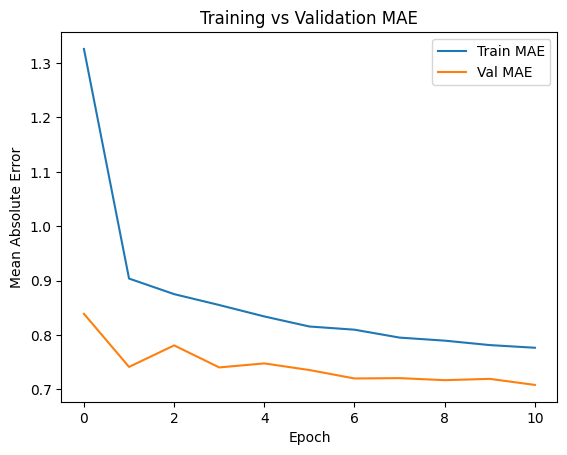

In [29]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')
plt.show()

In [30]:
y_pred = model.predict(x_test)

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [31]:
r2_score(y_test, y_pred)

-1.1635976390473255

In [32]:
# y_pred = model.predict(x_test).flatten()

In [33]:
# r2_score(np.expm1(y_test), np.expm1(y_pred))

In [34]:
from sklearn.metrics import mean_absolute_error

In [35]:
mean_absolute_error(y_test, y_pred)

0.8389542299485775

In [36]:
# mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

# **Denoising Autoencoder (DAE)**

## 📝 Task: Build a Simple Autoencoder for Noisy Data

## Objective
The dataset you are working with already contains a lot of **noise**.  
Your task is to build a **simple Autoencoder** that learns a cleaner representation of the features and produces latent features for downstream tasks.

---

## Steps

### 1️⃣ Prepare Data
- Use `X_train` and `X_test` directly.
- Ensure the input shape matches the number of features.

💡 *Hint: you can check it with `X_train.shape[1]`.*

---

### 2️⃣ Build Autoencoder
- Input layer = number of features.
- Encoder: one hidden dense layer (e.g., 64 units, ReLU).
- Decoder: one dense layer that reconstructs the input (linear activation).

💡 *Hint: Encoder reduces the dimensionality, Decoder reconstructs the original features.*

---

### 3️⃣ Train Autoencoder
- Train the model to reconstruct the inputs.
- Use `"mse"` loss and `"adam"` optimizer.
- Train for ~20 epochs, batch size 128.
- Validate on `(X_test, X_test)`.

💡 *Hint: the target is the same as the input (`X_train → X_train`).*

---

### 4️⃣ Extract Encoder
- Define a new model that outputs the **encoded layer** only.
- Transform `X_train` and `X_test` into latent features (`Z_train`, `Z_test`).

💡 *Hint: `encoder = Model(inputs, encoded_layer)`.*

---

## Deliverables
- Training and validation loss curve (plot).
- Latent features: print shape of `Z_train` and `Z_test`.
- Short reflection: *Do latent features seem more compact/cleaner than raw inputs?*


**Vanilla Autoencoder**

In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [39]:
x_train

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
19837,338.0,15.0,628.0,0.509709,1.0,0.645084,14.0,1.0,1.0,0.0,...,0.275971,0.033333,0.8,-0.259184,-0.500000,-0.100000,0.458333,0.333333,0.041667,0.333333
904,715.0,11.0,409.0,0.519608,1.0,0.657480,2.0,0.0,1.0,0.0,...,0.295343,0.136364,0.5,-0.133333,-0.166667,-0.100000,0.000000,0.000000,0.500000,0.000000
23876,262.0,7.0,345.0,0.609329,1.0,0.783920,5.0,2.0,1.0,0.0,...,0.428715,0.062500,0.6,-0.282639,-0.800000,-0.050000,0.000000,0.000000,0.500000,0.000000
22966,279.0,11.0,217.0,0.580189,1.0,0.775000,8.0,2.0,3.0,0.0,...,0.325667,0.033333,0.5,-0.098214,-0.125000,-0.071429,0.550000,0.200000,0.050000,0.200000
4705,647.0,13.0,123.0,0.739837,1.0,0.887324,3.0,0.0,1.0,0.0,...,0.444524,0.200000,1.0,-0.550000,-1.000000,-0.100000,0.000000,0.000000,0.500000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,616.0,8.0,123.0,0.723577,1.0,0.859155,3.0,0.0,0.0,1.0,...,0.352778,0.166667,0.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
11284,516.0,11.0,218.0,0.624390,1.0,0.716216,14.0,2.0,10.0,0.0,...,0.510606,0.250000,1.0,-0.147917,-0.187500,-0.050000,0.694444,0.375000,0.194444,0.375000
38158,35.0,11.0,172.0,0.666667,1.0,0.776699,5.0,3.0,2.0,0.0,...,0.357143,0.214286,0.5,-0.104233,-0.400000,-0.050000,0.150000,-0.050000,0.350000,0.050000
860,716.0,7.0,90.0,0.865169,1.0,0.923077,4.0,3.0,0.0,2.0,...,0.386667,0.100000,0.5,-0.200000,-0.200000,-0.200000,0.500000,0.250000,0.000000,0.250000


In [40]:
scaler_norm = MinMaxScaler()

x_train_min = scaler_norm.fit_transform(x_train)
x_test_min = scaler_norm.transform(x_test)

In [41]:
x_train_min.shape

(31715, 59)

In [42]:
n_features = x_train_min.shape[1]

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [44]:
autoencoder = Sequential([
    Input(shape=(n_features,)),

    # Encoder
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    # Decoder
    Dense(64, activation='relu'),
    Dense(n_features, activation='sigmoid')

])

In [53]:
autoencoder.compile(optimizer='adam', loss='mean_absolute_error')

In [63]:
history = autoencoder.fit(x_train_min, x_train_min,
                epochs=20,
                batch_size=128,
                validation_data=(x_test_min, x_test_min))

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0146 - val_loss: 0.0145
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0145 - val_loss: 0.0145
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0145 - val_loss: 0.0143
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143 - val_loss: 0.0142
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0142 - val_loss: 0.0143
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0142 - val_loss: 0.0143
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0140 - val_loss: 0.0140
Epoch 11/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0140 - val_loss: 0.0141
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

In [64]:
reconstructed_data = autoencoder.predict(x_test_min)

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step


In [65]:
test_loss = autoencoder.evaluate(x_test_min, x_test_min)

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0138


In [66]:
print(f'Test Reconstruction Loss: {test_loss}')

Test Reconstruction Loss: 0.01378606352955103


In [67]:
sample_index = 0

In [68]:
original_sample = x_test_min[sample_index:sample_index+1]
reconstructed_sample = reconstructed_data[sample_index:sample_index+1]

In [69]:
print(f'Orginal Sample: {original_sample[0, :5]}')
print(f'Reconstructed Sample: {reconstructed_sample[0, :5]}')

Orginal Sample: [0.15629322 0.47619048 0.13692162 0.00060202 0.00095969]
Reconstructed Sample: [0.17296822 0.47487253 0.13921177 0.00068016 0.00109291]


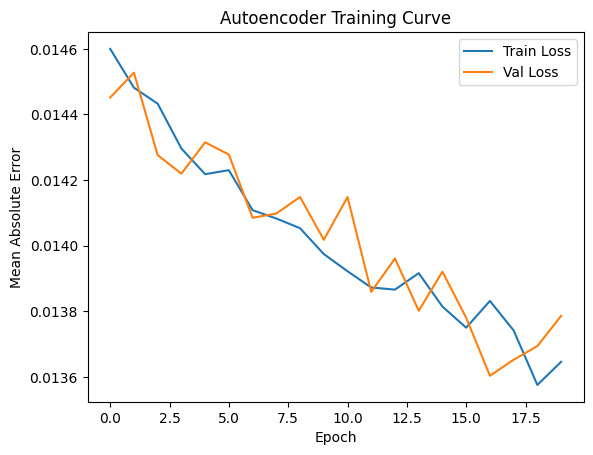

In [70]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Autoencoder Training Curve')
plt.show()